In [ ]:
# !pip install torch torchvision

In [7]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt



Train len 60000
Test len 10000
torch.Size([64, 1, 28, 28])


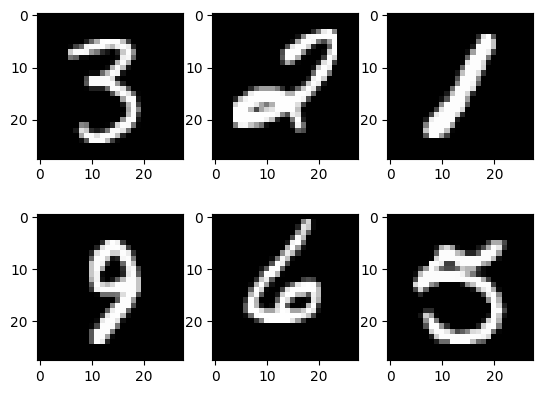

In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
print('Train len', len(train_dataset))
print('Test len', len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)
print(example_data.shape)
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(example_data[i][0], cmap='gray')
plt.show()




In [39]:
import torch.nn as nn

input_size = 28 * 28
hidden_size = 256
hidden_size2 = 128
output_size = 10

class mynnet(nn.Module):
    def __init__(self,input_size,hidden_size,hidden_size2,output_size):
        super(mynnet, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, hidden_size2)
        self.output_layer = nn.Linear(hidden_size2, output_size)
    def forward(self, x):
        x = x.view(-1, input_size)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.output_layer(x)
        return x

model = mynnet(input_size,hidden_size,hidden_size2,output_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Epoch :  1


100%|██████████| 938/938 [00:20<00:00, 46.70it/s]


Epoch :  2


100%|██████████| 938/938 [00:19<00:00, 47.13it/s]


Epoch :  3


...

Epoch :  4


100%|██████████| 938/938 [00:20<00:00, 46.50it/s]


Epoch :  5


100%|██████████| 938/938 [00:19<00:00, 49.13it/s]


Finished Training


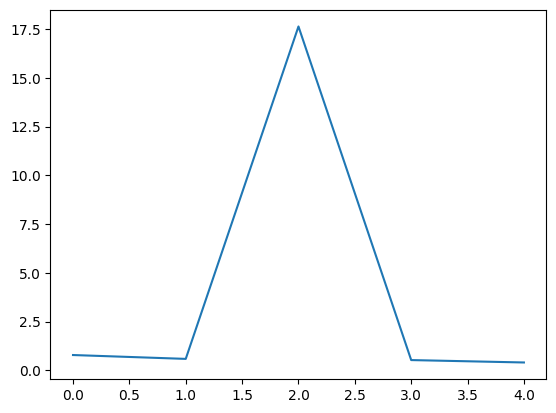

In [40]:
from tqdm import tqdm
epochs = 5
training_loss = []

for epoch in range(1,epochs+1):
  print("Epoch : ", epoch)
  running_loss = 0.0
  for i, data in enumerate(tqdm(train_loader),0):
    inputs, labels = data
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  training_loss.append(running_loss/len(train_loader))
print('Finished Training')

plt.plot(training_loss)
plt.show()


In [41]:
correct = 0
total = 0
test_labels = []
test_preds = []

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = model(images)
        _,predicted_output = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted_output == labels).sum().item()
        test_labels.extend(labels.numpy())
        test_preds.extend(predicted_output.numpy())

print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))


Accuracy of the network on the 10000 test images: 87 %


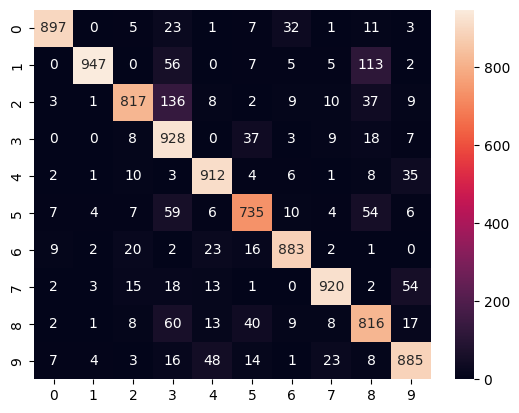

              precision    recall  f1-score   support

           0       0.97      0.92      0.94       980
           1       0.98      0.83      0.90      1135
           2       0.91      0.79      0.85      1032
           3       0.71      0.92      0.80      1010
           4       0.89      0.93      0.91       982
           5       0.85      0.82      0.84       892
           6       0.92      0.92      0.92       958
           7       0.94      0.89      0.91      1028
           8       0.76      0.84      0.80       974
           9       0.87      0.88      0.87      1009

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.88     10000
weighted avg       0.88      0.87      0.88     10000



In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

from sklearn.metrics import classification_report
print(classification_report(test_labels, test_preds))




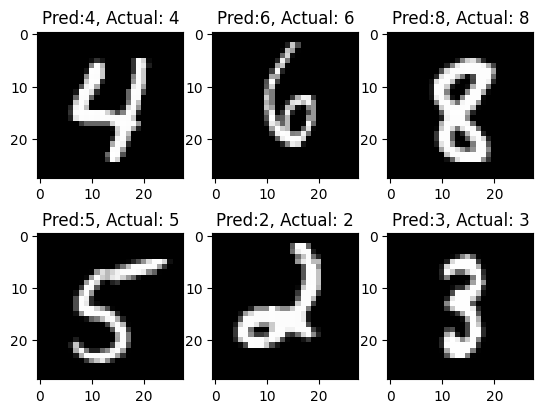

In [46]:
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)
import numpy as np
examples = enumerate(test_loader)
examples = enumerate(test_loader)

batch_idx, (example_data, example_targets) = next(examples)

with torch.no_grad():
    output = model(example_data)
    _, predictions = torch.max(output, 1)

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(example_data[i][0], cmap='gray')
    plt.title(f"Pred:{predictions[i].item()}, Actual: {example_targets[i].item()}")
plt.show()